In [ ]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import seaborn as sns
from collections import deque
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import joblib
import warnings
warnings.filterwarnings('ignore')
from google.colab import drive

drive.mount('/content/drive')

SAVE_PATH = "/content/drive/MyDrive/final_project/"
print("Imports done ✅")

Mounted at /content/drive
Imports done ✅


In [ ]:
SAVE_PATH = "/content/drive/MyDrive/final_project/"

df = pd.read_csv(
    SAVE_PATH + "customer_segments.csv"
)

print(f"Dataset shape : {df.shape}")
print(f"\nSegment distribution:")
print(df['segment'].value_counts())
print(f"\nColumns:")
print(df.columns.tolist())

Dataset shape : (41188, 24)

Segment distribution:
segment
🔴 Cold              26086
🔵 Neutral            8589
🟡 Warm Lead          3435
🔕 Do Not Disturb     1572
🟢 Hot Lead           1506
Name: count, dtype: int64

Columns:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y', 'segment', 'sentiment_score', 'behavioral_score', 'cluster']


In [ ]:
SAVE_PATH = "/content/drive/MyDrive/final_project/"

class CustomerEnvironment:
    def __init__(self, df):
        self.df          = df.reset_index(drop=True)
        self.n_customers = len(df)

        self.actions = {
            0: '📞 Call Now',
            1: '📱 Send SMS',
            2: '📧 Send Email',
            3: '⏳ Wait & Nurture',
            4: '🔕 Do Not Disturb'
        }
        self.n_actions = len(self.actions)

        self.ideal_action = {
            '🟢 Hot Lead'       : 0,
            '🟡 Warm Lead'      : 1,
            '🔵 Neutral'        : 2,
            '🔴 Cold'           : 3,
            '🔕 Do Not Disturb' : 4
        }

        self.reward_table = {
            # Hot Lead
            ('🟢 Hot Lead', 0): +15,
            ('🟢 Hot Lead', 1): -10,
            ('🟢 Hot Lead', 2): -10,
            ('🟢 Hot Lead', 3): -10,
            ('🟢 Hot Lead', 4): -15,

            # Warm Lead
            ('🟡 Warm Lead', 0): -10,
            ('🟡 Warm Lead', 1): +15,
            ('🟡 Warm Lead', 2): -10,
            ('🟡 Warm Lead', 3): -10,
            ('🟡 Warm Lead', 4): -15,

            # Neutral
            ('🔵 Neutral', 0): -15,
            ('🔵 Neutral', 1): -15,
            ('🔵 Neutral', 2): +15,
            ('🔵 Neutral', 3): -15,
            ('🔵 Neutral', 4): -15,

            # Cold
            ('🔴 Cold', 0): -15,
            ('🔴 Cold', 1): -10,
            ('🔴 Cold', 2): -5,
            ('🔴 Cold', 3): +15,
            ('🔴 Cold', 4): -5,

            # DND
            ('🔕 Do Not Disturb', 0): -15,
            ('🔕 Do Not Disturb', 1): -15,
            ('🔕 Do Not Disturb', 2): -10,
            ('🔕 Do Not Disturb', 3): -5,
            ('🔕 Do Not Disturb', 4): +15,
        }

        self.segment_indices = {}
        for seg in self.ideal_action.keys():
            idx = df[df['segment'] == seg]\
                .index.tolist()
            self.segment_indices[seg] = idx

        print("Segment indices:")
        for seg, idx in self.segment_indices.items():
            print(f"  {seg:25} : {len(idx)} customers")

    def get_balanced_indices(self, n_per_segment=25):
        indices = []
        for seg, idx_list in \
                self.segment_indices.items():
            sampled = np.random.choice(
                idx_list,
                min(n_per_segment, len(idx_list)),
                replace=False
            )
            indices.extend(sampled)
        np.random.shuffle(indices)
        return indices

    def get_state(self, idx):
        row = self.df.iloc[idx]

        # NO segment score — pure features only
        state = np.array([
            row['sentiment_score'],
            row['behavioral_score'],
            row['age']      / 100.0,
            row['campaign'] / 50.0,
            row['previous'] / 10.0,
            row['emp.var.rate']  / 5.0,
            row['cons.conf.idx'] / 100.0,
        ], dtype=np.float32)

        return state

    def step(self, idx, action):
        row       = self.df.iloc[idx]
        segment   = row['segment']
        sentiment = row['sentiment_score']
        risk      = row['behavioral_score']

        reward = self.reward_table.get(
            (segment, action), 0
        )

        # Sentiment aware bonus
        if sentiment > 0.7:
            reward += 2
        if risk > 0.8:
            reward += 2

        # Segment specific bonuses
        if segment == '🟢 Hot Lead':
            if sentiment > 0.7 and action == 0:
                reward += 3
            if risk > 0.8 and action == 0:
                reward += 3

        elif segment == '🟡 Warm Lead':
            if sentiment > 0.7 and action == 1:
                reward += 3
            if risk > 0.5 and action == 1:
                reward += 2

        elif segment == '🔵 Neutral':
            if action == 2:
                reward += 8
            if action == 3:
                reward -= 5
            if sentiment > 0.5 and action == 2:
                reward += 3
            if risk > 0.3 and action == 2:
                reward += 2

        elif segment == '🔴 Cold':
            if sentiment < 0.3 and action == 3:
                reward += 3
            if risk < 0.3 and action == 3:
                reward += 3

        elif segment == '🔕 Do Not Disturb':
            if risk < 0.2 and action == 4:
                reward += 3

        return reward

    def get_action_name(self, action):
        return self.actions[action]

env = CustomerEnvironment(df)
print(f"\nEnvironment created ✅")
print(f"State size  : 5")
print(f"Action size : {env.n_actions}")

Segment indices:
  🟢 Hot Lead                : 1506 customers
  🟡 Warm Lead               : 3435 customers
  🔵 Neutral                 : 8589 customers
  🔴 Cold                    : 26086 customers
  🔕 Do Not Disturb          : 1572 customers

Environment created ✅
State size  : 5
Action size : 5


In [ ]:
class DQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size    = state_size
        self.action_size   = action_size
        self.memory        = deque(maxlen=20000)

        self.gamma         = 0.90
        self.epsilon       = 1.0
        self.epsilon_min   = 0.05
        self.epsilon_decay = 0.9995
        self.learning_rate = 0.0001
        self.batch_size    = 64

        self.model        = self._build_model()
        self.target_model = self._build_model()
        self.update_target_model()

    def _build_model(self):
        model = Sequential([
            Dense(128, input_dim=self.state_size,
                  activation='relu'),
            Dropout(0.2),
            Dense(128, activation='relu'),
            Dropout(0.2),
            Dense(64,  activation='relu'),
            Dropout(0.1),
            Dense(self.action_size,
                  activation='linear')
        ])
        model.compile(
            optimizer=Adam(
                learning_rate=self.learning_rate,
                clipnorm=1.0
            ),
            loss='huber'
        )
        return model

    def update_target_model(self):
        self.target_model.set_weights(
            self.model.get_weights()
        )

    def remember(self, state, action,
                 reward, next_state):
        self.memory.append(
            (state, action, reward, next_state)
        )

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        q_values = self.model.predict(
            state.reshape(1, -1), verbose=0
        )
        return np.argmax(q_values[0])

    def replay(self):
        if len(self.memory) < self.batch_size:
            return 0

        batch       = random.sample(
            self.memory, self.batch_size
        )
        states      = np.array([b[0] for b in batch])
        actions     = np.array([b[1] for b in batch])
        rewards     = np.array([b[2] for b in batch])
        next_states = np.array([b[3] for b in batch])

        rewards = np.clip(rewards, -20, 25)

        targets = self.model.predict(
            states, verbose=0
        )
        next_q  = self.target_model.predict(
            next_states, verbose=0
        )

        for i in range(self.batch_size):
            targets[i][actions[i]] = (
                rewards[i] +
                self.gamma * np.max(next_q[i])
            )

        history = self.model.fit(
            states, targets,
            epochs=1, verbose=0
        )

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

        return history.history['loss'][0]

# Fresh agent — no leakage
STATE_SIZE  = 7
ACTION_SIZE = 5

agent = DQNAgent(STATE_SIZE, ACTION_SIZE)
print("DQN Agent created ✅")
print(f"State size    : {STATE_SIZE}")
print(f"Gamma         : {agent.gamma}")
print(f"Epsilon decay : {agent.epsilon_decay}")
print(f"Learning rate : {agent.learning_rate}")
agent.model.summary()

DQN Agent created ✅
State size    : 7
Gamma         : 0.9
Epsilon decay : 0.9995
Learning rate : 0.0001


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,117 (102.02 KB)

 Trainable params: 26,117 (102.02 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
SAVE_PATH = "/content/drive/MyDrive/final_project/"

EPISODES       = 200
N_PER_SEGMENT  = 25
UPDATE_TARGET  = 5

rewards_history = []
loss_history    = []
epsilon_history = []

print("Training DQN Agent (No Leakage)...")
print("=" * 50)

for episode in range(EPISODES):
    episode_reward = 0
    episode_loss   = 0
    steps          = 0

    indices = env.get_balanced_indices(
        n_per_segment=N_PER_SEGMENT
    )

    for idx in indices:
        state      = env.get_state(idx)
        action     = agent.act(state)
        reward     = env.step(idx, action)
        next_idx   = (idx + 1) % env.n_customers
        next_state = env.get_state(next_idx)

        agent.remember(
            state, action, reward, next_state
        )
        loss = agent.replay()

        episode_reward += reward
        episode_loss   += loss if loss else 0
        steps          += 1

    if episode % UPDATE_TARGET == 0:
        agent.update_target_model()

    avg_reward = episode_reward / steps
    avg_loss   = episode_loss   / steps

    rewards_history.append(avg_reward)
    loss_history.append(avg_loss)
    epsilon_history.append(agent.epsilon)

    if episode % 25 == 0:
        print(f"Episode {episode:3d}/{EPISODES} | "
              f"Avg Reward: {avg_reward:6.3f} | "
              f"Loss: {avg_loss:.4f} | "
              f"Epsilon: {agent.epsilon:.3f}")

print("\nTraining complete ✅")
print(f"Max reward  : {np.max(rewards_history):.3f}")
print(f"Mean reward : "
      f"{np.mean(rewards_history[-20:]):.3f}")

Training DQN Agent (No Leakage)...
Episode   0/200 | Avg Reward: -3.104 | Loss: 1.2423 | Epsilon: 0.969
Episode  25/200 | Avg Reward:  3.896 | Loss: 2.2340 | Epsilon: 0.203
Episode  50/200 | Avg Reward: 14.848 | Loss: 2.6264 | Epsilon: 0.050
Episode  75/200 | Avg Reward: 16.832 | Loss: 3.6840 | Epsilon: 0.050
Episode 100/200 | Avg Reward: 17.968 | Loss: 5.7657 | Epsilon: 0.050
Episode 125/200 | Avg Reward: 18.248 | Loss: 6.9362 | Epsilon: 0.050
Episode 150/200 | Avg Reward: 16.800 | Loss: 7.0825 | Epsilon: 0.050
Episode 175/200 | Avg Reward: 17.328 | Loss: 6.2522 | Epsilon: 0.050

Training complete ✅
Max reward  : 18.904
Mean reward : 17.724


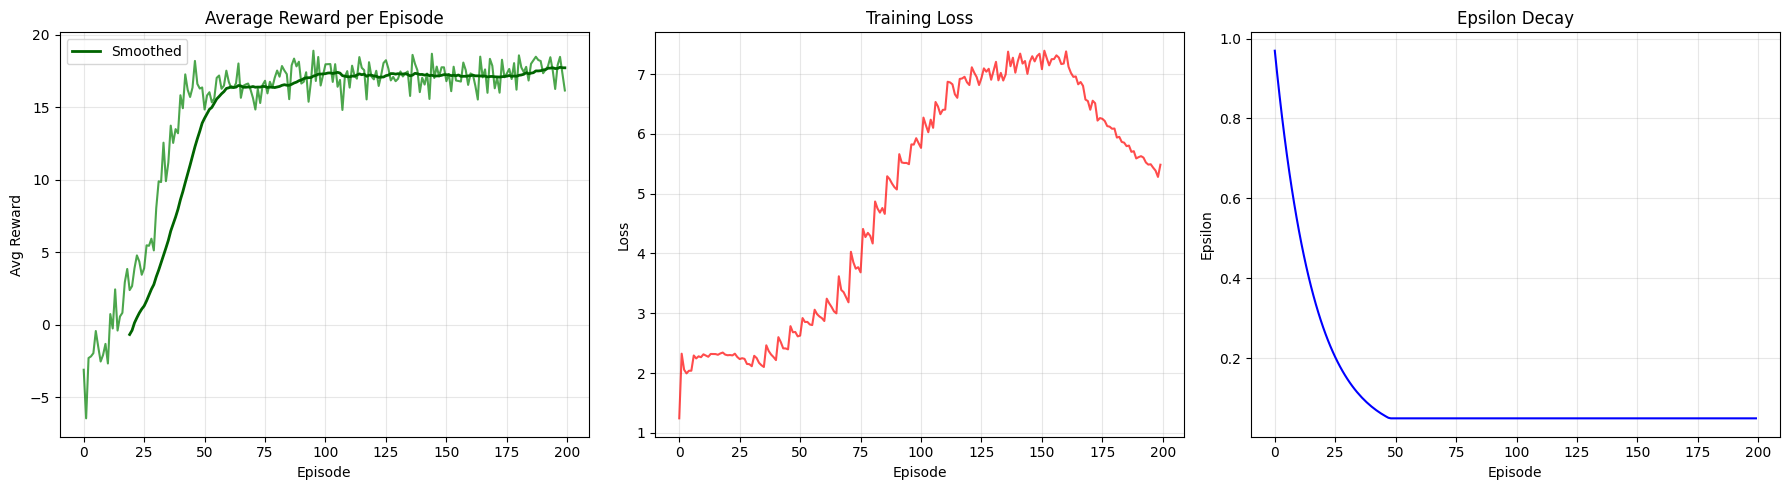

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(rewards_history,
             color='green', alpha=0.7)
smoothed = pd.Series(rewards_history)\
    .rolling(20).mean()
axes[0].plot(smoothed, color='darkgreen',
             linewidth=2, label='Smoothed')
axes[0].set_title('Average Reward per Episode')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Avg Reward')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(loss_history,
             color='red', alpha=0.7)
axes[1].set_title('Training Loss')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Loss')
axes[1].grid(True, alpha=0.3)

axes[2].plot(epsilon_history, color='blue')
axes[2].set_title('Epsilon Decay')
axes[2].set_xlabel('Episode')
axes[2].set_ylabel('Epsilon')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print("Evaluating DQN Agent...")
print("=" * 50)

print("Segment Distribution:")
print(df['segment'].value_counts())
print()

agent.epsilon = 0.0

all_states = np.array([
    [
        row['sentiment_score'],
        row['behavioral_score'],
        row['age']           / 100.0,
        row['campaign']      / 50.0,
        row['previous']      / 10.0,
        row['emp.var.rate']  / 5.0,
        row['cons.conf.idx'] / 100.0,
    ]
    for _, row in df.iterrows()
], dtype=np.float32)

print(f"State shape : {all_states.shape}")
assert all_states.shape[1] == 7, \
    "State size mismatch!"
print("No leakage confirmed ✅")

all_q         = agent.model.predict(
    all_states, batch_size=1024, verbose=0
)
actions_taken = np.argmax(all_q, axis=1)

rewards_received = np.array([
    env.step(i, actions_taken[i])
    for i in range(len(df))
])

ideal_actions = np.array([
    env.ideal_action.get(
        df.iloc[i]['segment'], -1
    )
    for i in range(len(df))
])

correct  = np.sum(actions_taken == ideal_actions)
accuracy = correct / len(df) * 100

print(f"\nTotal customers : {len(df)}")
print(f"Correct actions : {correct}")
print(f"Agent accuracy  : {accuracy:.2f}%")
print(f"Average reward  : {rewards_received.mean():.3f}")
print(f"Max reward      : {rewards_received.max():.3f}")
print(f"Min reward      : {rewards_received.min():.3f}")

print(f"\nAction Distribution:")
action_counts = pd.Series(actions_taken)\
    .value_counts()
for action_id, count in action_counts.items():
    pct  = count / len(df) * 100
    name = env.actions[action_id]
    print(f"  {name:25} : {count:6} ({pct:.1f}%)")

print(f"\nAccuracy Per Segment:")
for seg in env.ideal_action.keys():
    mask        = df['segment'] == seg
    seg_idx     = df[mask].index
    correct_seg = np.sum(
        actions_taken[seg_idx] ==
        env.ideal_action[seg]
    )
    total = len(seg_idx)
    print(f"  {seg:25} : "
          f"{correct_seg}/{total} "
          f"({correct_seg/total*100:.1f}%)")

Evaluating DQN Agent...
Segment Distribution:
segment
🔴 Cold              26086
🔵 Neutral            8589
🟡 Warm Lead          3435
🔕 Do Not Disturb     1572
🟢 Hot Lead           1506
Name: count, dtype: int64

State shape : (41188, 7)
No leakage confirmed ✅

Total customers : 41188
Correct actions : 39482
Agent accuracy  : 95.86%
Average reward  : 19.172
Max reward      : 27.000
Min reward      : -20.000

Action Distribution:
  ⏳ Wait & Nurture          :  24886 (60.4%)
  📧 Send Email              :   8663 (21.0%)
  📱 Send SMS                :   3536 (8.6%)
  🔕 Do Not Disturb          :   2671 (6.5%)
  📞 Call Now                :   1432 (3.5%)

Accuracy Per Segment:
  🟢 Hot Lead                : 1401/1506 (93.0%)
  🟡 Warm Lead               : 3250/3435 (94.6%)
  🔵 Neutral                 : 8384/8589 (97.6%)
  🔴 Cold                    : 24876/26086 (95.4%)
  🔕 Do Not Disturb          : 1571/1572 (99.9%)


In [ ]:
df['recommended_action'] = [
    env.actions[a] for a in actions_taken
]
df['reward']  = rewards_received
df['correct'] = actions_taken == ideal_actions

print("Sample Recommendations:")
sample = df[[
    'segment',
    'sentiment_score',
    'behavioral_score',
    'age',
    'campaign',
    'recommended_action',
    'reward',
    'correct'
]].sample(10, random_state=42).round(3)
print(sample.to_string(index=False))

print("\nAccuracy Per Segment:")
seg_acc = df.groupby('segment')['correct']\
    .mean() * 100
for seg, acc in seg_acc.items():
    print(f"  {seg:25} : {acc:.1f}%")

print("\nAverage Reward Per Segment:")
seg_rew = df.groupby('segment')['reward'].mean()
for seg, rew in seg_rew.items():
    print(f"  {seg:25} : {rew:.3f}")

Sample Recommendations:
  segment  sentiment_score  behavioral_score  age  campaign recommended_action  reward  correct
🔵 Neutral            0.304             0.309   57         1       📧 Send Email      25     True
   🔴 Cold            0.240             0.129   55         2   ⏳ Wait & Nurture      21     True
🔵 Neutral            0.246             0.345   33         1       📧 Send Email      25     True
   🔴 Cold            0.243             0.250   36         4   ⏳ Wait & Nurture      21     True
   🔴 Cold            0.245             0.286   27         2   ⏳ Wait & Nurture      21     True
   🔴 Cold            0.264             0.362   58         1   ⏳ Wait & Nurture      18     True
   🔴 Cold            0.321             0.188   48         1   ⏳ Wait & Nurture      18     True
   🔴 Cold            0.280             0.238   51         7   🔕 Do Not Disturb      -5    False
   🔴 Cold            0.250             0.283   24         4   ⏳ Wait & Nurture      21     True
   🔴 Cold       

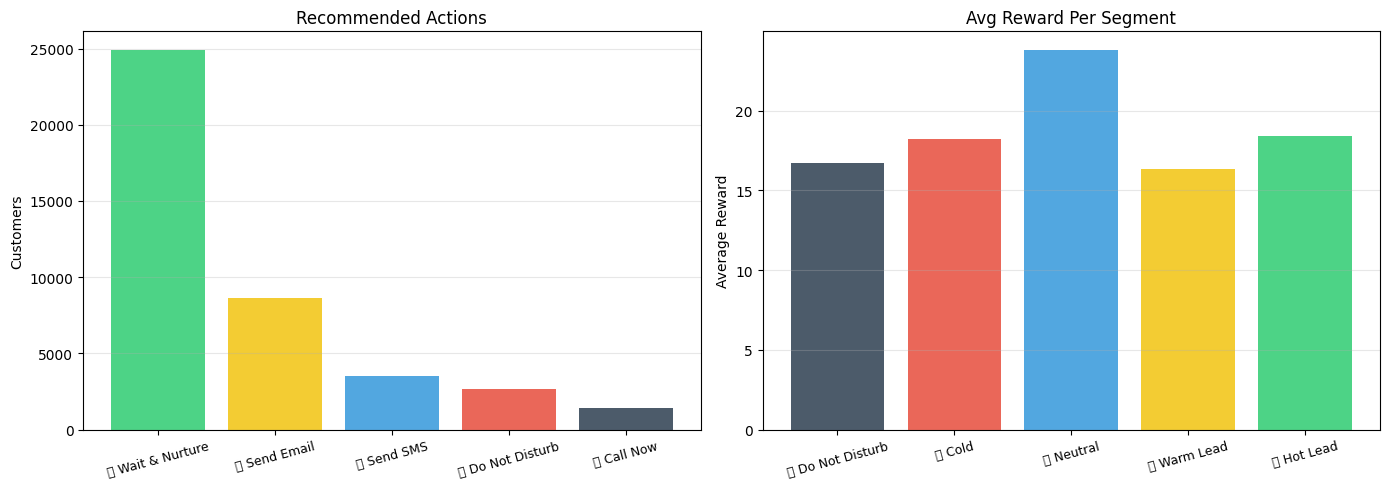

In [ ]:
colors_map = {
    '🟢 Hot Lead'       : '#2ecc71',
    '🟡 Warm Lead'      : '#f1c40f',
    '🔵 Neutral'        : '#3498db',
    '🔴 Cold'           : '#e74c3c',
    '🔕 Do Not Disturb' : '#2c3e50'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

action_dist = df['recommended_action']\
    .value_counts()
axes[0].bar(
    range(len(action_dist)),
    action_dist.values,
    color=['#2ecc71','#f1c40f',
           '#3498db','#e74c3c','#2c3e50'],
    alpha=0.85
)
axes[0].set_xticks(range(len(action_dist)))
axes[0].set_xticklabels(
    action_dist.index,
    rotation=15, fontsize=9
)
axes[0].set_title('Recommended Actions')
axes[0].set_ylabel('Customers')
axes[0].grid(True, alpha=0.3, axis='y')

seg_rewards = df.groupby('segment')['reward'].mean()
clrs = [colors_map.get(s, '#95a5a6')
        for s in seg_rewards.index]
axes[1].bar(
    range(len(seg_rewards)),
    seg_rewards.values,
    color=clrs, alpha=0.85
)
axes[1].set_xticks(range(len(seg_rewards)))
axes[1].set_xticklabels(
    seg_rewards.index,
    rotation=15, fontsize=9
)
axes[1].set_title('Avg Reward Per Segment')
axes[1].set_ylabel('Average Reward')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
import os
SAVE_PATH = "/content/drive/MyDrive/final_project/"

print("Current files in final_project:")
for f in sorted(os.listdir(SAVE_PATH)):
    print(f"  {f}")

Current files in final_project:
  bank_clean.csv
  behavioral_catboost.cbm
  behavioral_lightgbm.pkl
  behavioral_scores.npy
  behavioral_xgboost.pkl
  best_threshold.npy
  cluster_mapping.json
  customer_recommendations.csv
  customer_segments.csv
  feature_names.npy
  kmeans_model.pkl
  rewards_history.npy
  rl_agent.h5
  segment_scaler.pkl
  sentiment_scores.npy
  voice_labels.npy
  voice_sentiment_model.h5


In [ ]:
SAVE_PATH = "/content/drive/MyDrive/final_project/"

# This OVERWRITES yesterday's memorized model
agent.model.save(
    SAVE_PATH + "rl_agent.h5"
)
df.to_csv(
    SAVE_PATH + "customer_recommendations.csv",
    index=False
)
np.save(
    SAVE_PATH + "rewards_history.npy",
    np.array(rewards_history)
)

print("Updated model saved ✅ (replaced old version)")
print(f"New accuracy : {accuracy:.2f}%")
print(f"State size   : {all_states.shape[1]}")

Updated model saved ✅ (replaced old version)
New accuracy : 95.86%
State size   : 7


In [ ]:
# Cell 10 — Save
SAVE_PATH = "/content/drive/MyDrive/final_project/"

print(f"Agent accuracy : {accuracy:.2f}%")
print(f"State shape    : {all_states.shape}")

agent.model.save(
    SAVE_PATH + "rl_agent.h5"
)
df.to_csv(
    SAVE_PATH + "customer_recommendations.csv",
    index=False
)
np.save(
    SAVE_PATH + "rewards_history.npy",
    np.array(rewards_history)
)
print("\nAll files saved ✅")
print("  rl_agent.h5")
print("  customer_recommendations.csv")
print("  rewards_history.npy")

Agent accuracy : 95.86%
State shape    : (41188, 7)

All files saved ✅
  rl_agent.h5
  customer_recommendations.csv
  rewards_history.npy
